# HSE 2024: Mathematical Methods for Data Analysis

## Homework 2

# Attention!

* For tasks where <ins>text answer</ins> is required **Russian language** is **allowed**.
* If a task asks you to describe something (make coclusions) then **text answer** is **mandatory** and **is** part of the task
* **Do not** upload the dataset (titanic.csv) to the grading system (we already have it)
* We **only** accept **ipynb** notebooks. If you use Google Colab then you'll have to download the notebook before passing the homework
* **Do not** use python loops instead of NumPy vector operations over NumPy vectors - it significantly decreases performance (see why https://blog.paperspace.com/numpy-optimization-vectorization-and-broadcasting/), will be punished with -0.25 for **every** task.
Loops are only allowed in part 1 (Tasks 1 - 4).
* Some tasks contain tests. They only test you solution on a simple example, thus, passing the test does **not** guarantee you the full grade for the task.

If the task asks for an explanation of something, it means that a written answer is required, which is part of the task and is assessed

We only accept ipynb notebooks. If you use Google Colab, you need to download the notebook before submitting your homework

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn import datasets
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLSResults
from math import sqrt
import random
import sys
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

sns.set(style="darkgrid")

### Data

For this homework we will use a dataset of tracks from the streaming service Spotify

**Описание данных**

- **track_id:** The Spotify ID for the track
- **artists:** The artists' names who performed the track. If there is more than one artist, they are separated by a ;
- **album_name:** The album name in which the track appears
- **track_name:** Name of the track
- **popularity:** The popularity of a track is a value between 0 and 100, with 100 being the most popular. The popularity is calculated by algorithm and is based, in the most part, on the total number of plays the track has had and how recent those plays are. Generally speaking, songs that are being played a lot now will have a higher popularity than songs that were played a lot in the past. Duplicate tracks (e.g. the same track from a single and an album) are rated independently. Artist and album popularity is derived mathematically from track popularity.
- **duration_ms:** The track length in milliseconds
- **explicit:** Whether or not the track has explicit lyrics (true = yes it does; false = no it does not OR unknown)
- **danceability:** Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable
- **key:** The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1
- **loudness:** The overall loudness of a track in decibels (dB)
- **mode:** Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0
- **speechiness:** Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks
- **acousticness:** A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic
- **instrumentalness:** Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content
- **liveness:** Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live
- **valence:** A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)
- **tempo:** The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration
- **time_signature:** An estimated time signature. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure). The time signature ranges from 3 to 7 indicating time signatures of 3/4, to 7/4.
- **track_genre:** The genre in which the track belongs

**Target variable**
- **energy:** Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale

In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 5.6 MB/s eta 0:00:00


In [ ]:
pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9656 sha256=95d9fccb10fcc6944df83009c190aa0898c1fa449cfd90c331c727abb7291cd5
  Stored in directory: /root/.cache/pip/wheels/8b/f1/7f/5c94f0a7a505ca1c81cd1d9208ae2064675d97582078e6c769
Successfully built wget


In [ ]:
import wget
url = 'https://raw.githubusercontent.com/darkydash/ml_hse/refs/heads/main/hw2/dataset.csv'
filename = wget.download(url)
filename

'dataset.csv'

In [ ]:
data = pd.read_csv('dataset.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  object 
 1   album_name        113999 non-null  object 
 2   track_name        113999 non-null  object 
 3   popularity        114000 non-null  int64  
 4   duration_ms       114000 non-null  int64  
 5   explicit          114000 non-null  bool   
 6   danceability      114000 non-null  float64
 7   energy            114000 non-null  float64
 8   key               114000 non-null  int64  
 9   loudness          114000 non-null  float64
 10  mode              114000 non-null  int64  
 11  speechiness       114000 non-null  float64
 12  acousticness      114000 non-null  float64
 13  instrumentalness  114000 non-null  float64
 14  liveness          114000 non-null  float64
 15  valence           114000 non-null  float64
 16  tempo             11

Перед тем как работать с моделью мы видим что у нас есть null значения причем всего 3 на 114000 строк, поэтому удалим их, в первую очередь в этом задании для того чтобы не кодировать null value in categorical features

In [ ]:
data.dropna(inplace=True)
y = data['energy']
x = data.drop(['energy'], axis=1)
columns = x.columns

## Linear Regression

#### 0. [0.25 points] Code the categorical features. Explain the method you have chosen.

In [ ]:
print(x.info())
print(f"\nКатегориальные признаки: {(categorical_features := x.select_dtypes(include=['object']).columns).tolist()}")

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  object 
 1   album_name        113999 non-null  object 
 2   track_name        113999 non-null  object 
 3   popularity        113999 non-null  int64  
 4   duration_ms       113999 non-null  int64  
 5   explicit          113999 non-null  bool   
 6   danceability      113999 non-null  float64
 7   key               113999 non-null  int64  
 8   loudness          113999 non-null  float64
 9   mode              113999 non-null  int64  
 10  speechiness       113999 non-null  float64
 11  acousticness      113999 non-null  float64
 12  instrumentalness  113999 non-null  float64
 13  liveness          113999 non-null  float64
 14  valence           113999 non-null  float64
 15  tempo             113999 non-null  float64
 16  time_signature    113999 

Из полученной таблицы и описания признаков по условию распределим признаки на группы:  
Numerical:  
*   duration_ms
*   danceability
*   loudness
*   speechiness
*   acousticness
*   instrumentalness
*   liveness
*   valence
*   tempo  

Binary:
*   explicit
*   mode

Categorical:  

*   artists
*   album_name
*   track_name
*   track_genre

Ordinal:
*   popularity
*   key
*   time_signature   

Numerical признаки уже имеют числовой вид и я не вижу смысла изменять их на данном этапе, для бинарных данных достаточно просто использовать OrdinalEncoder и заменить true и false на 1 и 0(модель работает и с bool поэтому их можно не трогать). Далее мы понимаем что у нас 4 категориальных признака: ['artists', 'album_name', 'track_name', 'track_genre']. И еще 3 порядковых : ['popularity', 'key', 'time_signature'].
Ordinal признаки уже имеют порядок внутри себя, и если к ним применять one-hot encoding, мы потеряем информацию о связи внутри них. Единственное, что бы я сделал это отнормировал каждый такой признак на отрезок [0,1](Но в линейной регрессии StandartScaler и так сделает это). Теперь наконец разберемся с категориальными признаками.
Сейчас у нас уже много признаков, поэтому просто использовать one-hot encoding будет не разумно, мы можем увеличить количество признаков в разы. Поэтому
для остальных признаков давайте сначала посмотрим сколько у каждого уникальных значений.  


In [ ]:
x[categorical_features].nunique()

,0
artists,31437
album_name,46589
track_name,73608
track_genre,114


Понимаем, что для artists, track_name и album_name one-hot encoding точно не подходит, из-за огромного количества видов уникальных данных. Дальше можно сделать просто label encoding и присвоить названиям числа от 1 до n, но тогда мы присваиваем данным избыточную зависимость между собой. Давайте посмотрим сколько раз повторяется каждое название песни и название альбома и имя исполнителя.

In [ ]:
print(f"{(x['track_name'].value_counts()<5).sum()/x[categorical_features].nunique().loc['track_name'] * 100:.2f}%")
print(f"{(x['album_name'].value_counts()<10).sum()/x[categorical_features].nunique().loc['album_name'] * 100:.2f}%")
print(f"{(x['artists'].value_counts()<5).sum()/x[categorical_features].nunique().loc['artists'] * 100:.2f}%")
print(f"{(x['track_genre'].value_counts()<100).sum()/x[categorical_features].nunique().loc['track_genre'] * 100:.2f}%")


97.00%
97.09%
84.38%
0.00%


Давайте сначала напишем one hot binary encoding, а затем объясним его выбор и отбрасывание признаков. Его идея в том чтобы сначала для каждого названия(песни/исполнителя/альбома) найти сколько раз он встречается - count_object. Затем раз у нас много уникальных имен есть метод categorize_item который в зависимости от фактора объединяет названия в редкие группы и собственно сам binaryencoder который представляет потом категории как двоичное число.

In [ ]:
import category_encoders as ce

# Нам дается категориальынй признак и мы создаем столбец с количеством повторений для каждой сущности этого признака
def count_object(column_name,dataframe):
  count = dataframe[column_name].value_counts()
  dataframe[f'{column_name}_count'] = dataframe[column_name].map(count)

# Метод для объединения редких элементов column_name в единые группы, где редкость определяется factor
def categorize_item(row, column_name,factor):
    column_count = f'{column_name}_count'
    if row[column_count] > factor:
        return row[column_name]
    else:
        return f'Rare {row[column_count]}'
# Для каждой строки определяем необходимо ли атрибут отнести к редкой группе
def refactor_catecorical_column(dataframe,column_name,factor):
  dataframe[column_name] = x.apply(lambda row: categorize_item(row, column_name, factor), axis=1)

def One_Hot_BinaryEncoder(dataframe,column_name,factor):
  count_object(column_name,dataframe)
  refactor_catecorical_column(dataframe,column_name,factor)
  encoder = ce.BinaryEncoder(cols=[column_name])
  return encoder.fit_transform(dataframe)

In [ ]:
x = One_Hot_BinaryEncoder(dataframe = x,column_name = 'artists',factor = 5)
# x = One_Hot_BinaryEncoder(dataframe = x,column_name = 'album_name',factor = 10)
# x = One_Hot_BinaryEncoder(dataframe = x,column_name = 'track_name',factor = 5)
x = One_Hot_BinaryEncoder(dataframe = x,column_name = 'track_genre',factor = 0)

Во-первых, врятли именно название трека и альбома влияют на целевую переменную-энергичность. Во-вторых 97% данных таких названий представлют из себя названия которые встречаются менее 5 и 10 раз соответственно,уникальны по сравнению с массивом данных в 114 000.  
То есть в целом использовать информацию о почти уникальных именах для каждой строки не имеет много смысла при анализе target. Поэтому было принято решение не рассматривать эти 2 признака при обучении.  
(Я переписал изначальное решение в виде функций, и в итоге если это критично, то что я отбрасываю 2 признака то достаточно раскомментировать 2 строки выше и эти переменные тоже закодируются. Но я прогонял как с ними так и без них и результат не меняется, но количество признаков увеличивается + 22, что подтверждает мою теорию о незначимости этих признаков на target переменную).
По таким же причинам можно было бы отбросить признак исполнителя, но я мотивировался тем, что треки одного исполнителя похожи по многим признакам, в том числе, возможно, по target переменной, поэтому хочется закодировать переменную artists. Для этого опять же посмотрим сколько артистов встречаются редко Я принял решение объединить артистов с 1 - 5 песней в категории Rare1, Rare2, Rare3, Rare4, Rare5. Опять же проблема c one hot encoding и label encoding. Поэтому я принял решение сделать binary encoder где добавиться логарифм от количества артистов признаков то есть + 12 признаков. Аналогично сырой one-hot для жанров музыки добавит 100 признаков, упорядочивать жанры с помощью label encoding не хочется потому что они все равноправны поэтому также binary encode жанры музыки то есть + 7 признаков

In [ ]:
print(x.info())

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 37 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   artists_0          113999 non-null  int64  
 1   artists_1          113999 non-null  int64  
 2   artists_2          113999 non-null  int64  
 3   artists_3          113999 non-null  int64  
 4   artists_4          113999 non-null  int64  
 5   artists_5          113999 non-null  int64  
 6   artists_6          113999 non-null  int64  
 7   artists_7          113999 non-null  int64  
 8   artists_8          113999 non-null  int64  
 9   artists_9          113999 non-null  int64  
 10  artists_10         113999 non-null  int64  
 11  artists_11         113999 non-null  int64  
 12  album_name         113999 non-null  object 
 13  track_name         113999 non-null  object 
 14  popularity         113999 non-null  int64  
 15  duration_ms        113999 non-null  int64  
 16  explici

In [ ]:
# Преобразовали булев тип в int
x['explicit'] = x['explicit'].astype(int)

#### 1. [0.25 points] Split the data into train and test with a ratio of 80:20 and random_state=42.

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### 2. [0.75 points] Train models on train, excluding categorical features, using the StatsModels library and apply it to test; use $RMSE$ and $R^2$ as quality metrics. Try also applying linear regression implementations from sklearn:

* [`LinearRegression`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html);
* [`Ridge`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) with $\alpha = 0.03$;
* [`Lasso`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) with $\alpha = 0.05$

Don't forget to scale your data using StandardScaler before training your models!

Если мы убираем все категориальные фичи то их названия начинаются с '^(artists|album|track)', если их оставлять то надо убрать вспомогательные таблицы а также то, что мы не кодировали '(count\$|album_name\$|track_name\$|artists\$|track_genre\$|)'

In [ ]:
def searchMetrics(y_pred_train,y_train,y_pred_test,y_test):
  rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
  r2_train = r2_score(y_train, y_pred_train)

  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
  r2_test = r2_score(y_test, y_pred_test)

  return (rmse_train,r2_train,rmse_test,r2_test)

In [ ]:
def dropData(x_train,x_test,regex):

  columns_to_drop = x_train.filter(regex=regex).columns
  return (x_train.drop(columns = columns_to_drop),x_test.drop(columns = columns_to_drop))

In [ ]:
def scalledData(x_train,x_test):
  #scaling us data
  scaler = StandardScaler()
  x_train_scaled = scaler.fit_transform(x_train)
  x_test_scaled = scaler.transform(x_test)
  return (x_train_scaled,x_test_scaled)

In [ ]:
def resultsShow(model,rmse_train,r2_train,rmse_test,r2_test):
  print(f"Train {model} - RMSE: {rmse_train:.5f}, R^2: {r2_train:.5f}")
  print(f"Test {model} - RMSE: {rmse_test:.5f}, R^2: {r2_test:.5f}")

 StatsModels library

In [ ]:
def LinRegStatsModels(x_train,x_test,y_train,y_test,regex):
  x_train_without_cf,x_test_without_cf = dropData(x_train,x_test,regex)
  x_train_scalled,x_test_scalled = scalledData(x_train_without_cf,x_test_without_cf)

  # обучаем модель
  x_train_sm = sm.add_constant(x_train_scalled)
  x_test_sm = sm.add_constant(x_test_scalled)

  model_sm = sm.OLS(y_train, x_train_sm)
  results = model_sm.fit()
  print(results.summary2())

  # Работа модели на тестовой и тренировочной выборке
  y_pred_train_sm = results.predict(x_train_sm)
  y_pred_test_sm = results.predict(x_test_sm)

  rmse_train_sm,r2_train_sm,rmse_test_sm,r2_test_sm = searchMetrics(y_pred_train_sm,y_train,y_pred_test_sm,y_test)

  resultsShow('StatsModel',rmse_train_sm,r2_train_sm,rmse_test_sm,r2_test_sm)
  return results

In [ ]:
LinRegStatsModels(x_train,x_test,y_train,y_test,'^(artists|album|track)')

                   Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.766       
Dependent Variable: energy           AIC:                -125307.5465
Date:               2024-10-23 09:10 BIC:                -125166.2345
No. Observations:   91199            Log-Likelihood:     62669.      
Df Model:           14               F-statistic:        2.133e+04   
Df Residuals:       91184            Prob (F-statistic): 0.00        
R-squared:          0.766            Scale:              0.014816    
-----------------------------------------------------------------------
             Coef.    Std.Err.       t       P>|t|     [0.025    0.975]
-----------------------------------------------------------------------
const        0.6409     0.0004   1589.9561   0.0000    0.6401    0.6416
x1          -0.0022     0.0004     -5.4291   0.0000   -0.0030   -0.0014
x2           0.0047     0.0004     11.3462   0.0000    0.0039    0.0055
x3          -0.0020     0.0

In [ ]:
def scklearnModels(name,model,x_train,x_test,y_train,y_test,regex):
  x_train_without_cf,x_test_without_cf = dropData(x_train,x_test,regex)
  x_train_scaled,x_test_scaled = scalledData(x_train_without_cf,x_test_without_cf)

  model.fit(x_train_scaled, y_train)

  y_train_pred = model.predict(x_train_scaled)
  y_test_pred = model.predict(x_test_scaled)

  rmse_train,r2_train,rmse_test,r2_test = searchMetrics(y_train_pred,y_train,y_test_pred,y_test)

  resultsShow(name,rmse_train,r2_train,rmse_test,r2_test)

In [ ]:
model = Ridge(alpha=0.03)
regex = '^(artists|album|track)'
scklearnModels('RidgeModel',model,x_train,x_test,y_train,y_test,regex)

Train RidgeModel - RMSE: 0.12171, R^2: 0.76609
Test RidgeModel - RMSE: 0.12182, R^2: 0.76447


In [ ]:
model = Lasso(alpha=0.05)
regex = '^(artists|album|track)'
scklearnModels('LassoModel',model,x_train,x_test,y_train,y_test,regex)

Train LassoModel - RMSE: 0.14776, R^2: 0.65525
Test LassoModel - RMSE: 0.14813, R^2: 0.65174


In [ ]:
model = LinearRegression()
regex = '^(artists|album|track)'
scklearnModels('LinearRegretion',model,x_train,x_test,y_train,y_test,regex)

Train LinearRegretion - RMSE: 0.12171, R^2: 0.76609
Test LinearRegretion - RMSE: 0.12182, R^2: 0.76447


#### 3. [0.25 points] Repeat the steps from the previous point, adding categorical features. Comment on the changes in the quality metrics values

In [ ]:
LinRegStatsModels(x_train,x_test,y_train,y_test,'(count$|album_name$|track_name$|artists$|track_genre$)')

                   Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.769       
Dependent Variable: energy           AIC:                -126257.3194
Date:               2024-10-23 09:10 BIC:                -125937.0122
No. Observations:   91199            Log-Likelihood:     63163.      
Df Model:           33               F-statistic:        9176.       
Df Residuals:       91165            Prob (F-statistic): 0.00        
R-squared:          0.769            Scale:              0.014660    
-----------------------------------------------------------------------
             Coef.    Std.Err.       t       P>|t|     [0.025    0.975]
-----------------------------------------------------------------------
const        0.6409     0.0004   1598.4232   0.0000    0.6401    0.6416
x1           0.0001     0.0005      0.2826   0.7775   -0.0008    0.0011
x2          -0.0020     0.0005     -4.4284   0.0000   -0.0029   -0.0011
x3          -0.0089     0.0

In [ ]:
model = Ridge(alpha=0.03)
regex = '(count$|album_name$|track_name$|artists$|track_genre$)'
scklearnModels('RidgeModel',model,x_train,x_test,y_train,y_test,regex)

Train RidgeModel - RMSE: 0.12105, R^2: 0.76861
Test RidgeModel - RMSE: 0.12110, R^2: 0.76724


In [ ]:
model = Lasso(alpha=0.05)
regex = '(count$|album_name$|track_name$|artists$|track_genre$)'
scklearnModels('LassoModel',model,x_train,x_test,y_train,y_test,regex)

Train LassoModel - RMSE: 0.14776, R^2: 0.65525
Test LassoModel - RMSE: 0.14813, R^2: 0.65174


In [ ]:
model = LinearRegression()
regex = '(count$|album_name$|track_name$|artists$|track_genre$)'
scklearnModels('LinearRegression',model,x_train,x_test,y_train,y_test,regex)

Train LinearRegression - RMSE: 0.12105, R^2: 0.76861
Test LinearRegression - RMSE: 0.12110, R^2: 0.76724


Во первых, для линейной регрессии у нас огромное количество данных, и при таком разделении на test/train результаты предсказаний на тренировчной выборке хорошо обобщаются на тестовую выборку, в связи с этим предсказания на обоих выборках довольно схожи(погрешность 1%).
Во вторых после добавления категориальных параметров, метрики качества почти не изменяются.
По моему мнению это связано со следующими причинами:


1.   Довольно редко реальные данные линейно от чего то зависят, вероятно в данном контексте зависимость может описываться более сложной моделью, поэтому добавление новых признаков хоть и немного улучшило показатели, но в целом результаты не изменились, из-за возможной нелинейно связи target и X
2.   Сама переменная target = energy врятли зависит от исполнителя или от жанра музыки напрямую. Числовые данные например: тональность, танцевальность, популярность liveness и другие могут более вероятно определять target переменную. И например, жанр музыки строится из этих числовых показателей, поэтому стоит проверить категориальные признаки на мультиколлинеарность, из-за этого categorialy features могут и не влиять сильно на target
3.  По сути это уже было раскрыто во 2 пункте, но также если у нас уже присутсвует сильная линейная зависмость от числовых признаков, то доп признаки не будут существенно влиять на результаты.

Но все таки показатели увеличились,и модель обучилась лучше с категориальными признаками, по крайней мере для MS, Linear Regression и Ridge, для которых коэффициент детерминации немного увеличивается, а средняя ошибка падает.
Без категориальных:

|Model             | Train_rmse  |Train_r2    |Test_rmse|Test_r2  |
|------------------|-------------|------------|---------|---------|
| MS               | 0.12171     | 0.76609    |0.12182  | 0.76447 |
| Ridge            | 0.12171     | 0.76609    |0.12182  |0.76447  |
| Lasso            | 0.14776     | 0.65525    |0.14813  |0.65174  |
| Linear Regression| 0.12171     | 0.76609    |0.12182  |0.76447  |


|Model             | Train_rmse  |Train_r2    |Test_rmse|Test_r2  |
|------------------|-------------|------------|---------|---------|
| MS               | 0.12105     | 0.76861    |0.12110  | 0.76724 |
| Ridge            | 0.12105     | 0.76861    |0.12110  | 0.76724 |
| Lasso            | 0.14776     | 0.65525    |0.14813  |0.65174  |
| Linear Regression| 0.12105     | 0.76861    |0.12110  |0.76724  |







#### 4. [1 point] Examine the parameter values ​​of the models obtained from StatsModels and check which weights and in which models turned out to be zero. Comment on the significance of the coefficients, the overall significance of the models and other factors from the resulting tables

In [ ]:
res_without = LinRegStatsModels(x_train,x_test,y_train,y_test,'^(artists|album|track)')

                   Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.766       
Dependent Variable: energy           AIC:                -125307.5465
Date:               2024-10-23 09:34 BIC:                -125166.2345
No. Observations:   91199            Log-Likelihood:     62669.      
Df Model:           14               F-statistic:        2.133e+04   
Df Residuals:       91184            Prob (F-statistic): 0.00        
R-squared:          0.766            Scale:              0.014816    
-----------------------------------------------------------------------
             Coef.    Std.Err.       t       P>|t|     [0.025    0.975]
-----------------------------------------------------------------------
const        0.6409     0.0004   1589.9561   0.0000    0.6401    0.6416
x1          -0.0022     0.0004     -5.4291   0.0000   -0.0030   -0.0014
x2           0.0047     0.0004     11.3462   0.0000    0.0039    0.0055
x3          -0.0020     0.0

Таблица характеристик для модели без категориальных признаков. Давайте сначала исследуем веса нашей линейной модели.

In [ ]:
coefficients = res_without.params
zero_weights = coefficients[coefficients == 0]
almost_zero_weights = coefficients[abs(coefficients) < 0.001]
print(f'Нулевые веса: {zero_weights}')
print(f'Веса близкие к 0: {almost_zero_weights}')
print(f'Минимальный вес: {min(abs(coefficients))}')

Нулевые веса: Series([], dtype: float64)
Веса близкие к 0: Series([], dtype: float64)
Минимальный вес: 0.0014654739628496632


Все веса получились не нулевыми, минимальный вес 0.0015. Для того чтобы понять какие веса больше влияют на target и значимсоть весов, обратимся к p-value и t-value

In [ ]:
print(res_without.pvalues)
print(f'Количество значимых признаков для модели на уровне значимости 0.05: {(res_without.pvalues<0.05).sum()}')
print(f'Всего признаков: {len(res_without.pvalues)}')

const    0.000000e+00
x1       5.678881e-08
x2       8.108586e-30
x3       3.812956e-06
x4       0.000000e+00
x5       3.210113e-04
x6       0.000000e+00
x7       1.478849e-21
x8       0.000000e+00
x9       0.000000e+00
x10      0.000000e+00
x11      0.000000e+00
x12      0.000000e+00
x13      1.389621e-68
x14      7.320466e-65
dtype: float64
Количество значимых признаков для модели на уровне доверия 0.05: 15
Всего признаков: 15


То есть все признаки значимы для модели. Отсортировав по t-value, поймем какие признаки оказывают больше/меньше всего влияния на target

In [ ]:
print('Признаки которые оказывают наибольшее влияние ')
print(res_without.tvalues.abs().sort_values(ascending=False).iloc[1:4])
print('Признаки которые оказывают наименьшее влияние ')
print(res_without.tvalues.abs().sort_values(ascending=False).iloc[-3:])

Признаки которые оказывают наибольшее влияние 
x6     234.009522
x9     202.154788
x12     82.101980
dtype: float64
Признаки которые оказывают наименьшее влияние 
x1    5.429082
x3    4.621609
x5    3.597864
dtype: float64


Для оценки качества модели найдем значение коэффициента детерминации и его скорретированной версии.

In [ ]:
print(f"R-squared: {res_without.rsquared}")
print(f"Adjusted R-squared: {res_without.rsquared_adj}")

# F-statistic и его P-значение
print(f"F-statistic: {res_without.fvalue}")
print(f"P-value for F-statistic: {res_without.f_pvalue}")


R-squared: 0.7660903058207995
Adjusted R-squared: 0.7660543923302912
F-statistic: 21331.546863810192
P-value for F-statistic: 0.0


Последним шагом будет проверить общую значимость модели, для этого рассчитаем критическое значение F статистики

In [ ]:
F_critical = stats.f.ppf(0.95, 14, len(y_train) - 15)
print(f"Критическое значение F: {F_critical}")

Критическое значение F: 1.6918792051441223


**Давайте сначала рассчитаем все показатели для 2ой модели с категориальными признаками, а затем проанализируем их и сравним**

In [ ]:
res_with = LinRegStatsModels(x_train,x_test,y_train,y_test,'(count$|album_name$|track_name$|artists$|track_genre$)')

                   Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.769       
Dependent Variable: energy           AIC:                -126257.3194
Date:               2024-10-23 10:24 BIC:                -125937.0122
No. Observations:   91199            Log-Likelihood:     63163.      
Df Model:           33               F-statistic:        9176.       
Df Residuals:       91165            Prob (F-statistic): 0.00        
R-squared:          0.769            Scale:              0.014660    
-----------------------------------------------------------------------
             Coef.    Std.Err.       t       P>|t|     [0.025    0.975]
-----------------------------------------------------------------------
const        0.6409     0.0004   1598.4232   0.0000    0.6401    0.6416
x1           0.0001     0.0005      0.2826   0.7775   -0.0008    0.0011
x2          -0.0020     0.0005     -4.4284   0.0000   -0.0029   -0.0011
x3          -0.0089     0.0

In [ ]:
coefficients = res_with.params
zero_weights = coefficients[coefficients == 0]
almost_zero_weights = coefficients[abs(coefficients) < 0.001]
print(f'Нулевые веса: {zero_weights}')
print(f'Веса близкие к 0: {almost_zero_weights}')
print(f'Минимальный вес: {min(abs(coefficients))}\n')
print(f"-------------------------------------------")

print(f'         p_values\n {res_with.pvalues}')
print(f'Количество значимых признаков для модели на уровне значимости 0.05: {(res_with.pvalues<0.05).sum()}')
print(f'Всего признаков: {len(res_with.pvalues)}\n')
print(f"-------------------------------------------")

print('Признаки которые оказывают наибольшее влияние ')
print(res_with.tvalues.abs().sort_values(ascending=False).iloc[1:4])
print('Признаки которые оказывают наименьшее влияние ')
print(res_with.tvalues.abs().sort_values(ascending=False).iloc[-3:])
print(f"-------------------------------------------")

print(f"\nR-squared: {res_with.rsquared}")
print(f"Adjusted R-squared: {res_with.rsquared_adj}")

print(f"F-statistic: {res_with.fvalue}")
print(f"P-value for F-statistic: {res_with.f_pvalue}")
print(f"-------------------------------------------")

F_critical = stats.f.ppf(0.95, 33, len(y_train) - 34)
print(f"\nКритическое значение F: {F_critical}")


Нулевые веса: Series([], dtype: float64)
Веса близкие к 0: x1     0.000139
x5    -0.000704
x7     0.000959
x9    -0.000594
x10    0.000795
x11    0.000440
x12   -0.000456
x27   -0.000163
x30    0.000603
x33   -0.000395
dtype: float64
Минимальный вес: 0.00013892170300478177

-------------------------------------------
         p_values
 const    0.000000e+00
x1       7.775079e-01
x2       9.504459e-06
x3       9.150311e-81
x4       1.068187e-16
x5       1.180100e-01
x6       2.617799e-64
x7       3.428451e-02
x8       1.583392e-02
x9       1.787436e-01
x10      6.285411e-02
x11      3.206091e-01
x12      2.926864e-01
x13      5.510651e-10
x14      3.214085e-29
x15      4.030071e-07
x16      0.000000e+00
x17      9.464523e-04
x18      0.000000e+00
x19      3.702977e-21
x20      0.000000e+00
x21      0.000000e+00
x22      0.000000e+00
x23      0.000000e+00
x24      0.000000e+00
x25      2.244589e-75
x26      2.151907e-66
x27      7.213197e-01
x28      1.295533e-20
x29      1.225341e-02
x3

И так мы рассчитали факторы для двух моделей. Теперь проанализируем их:


**1.   Нулевые веса.**

В обеих моделях нулевых весов не оказалось, что отбрасывает явные признаки, которые вообще не влияют на target. Но рассмотрев веса близкие к 0(а именно <0.001), мы получим что таких весов нет для 1ой модели, но для модели с категориальными признаками их уже 10. Что на самом деле предсказуемо,количество фичей увеличилось, и каждый признак не может сильно влиять на target. Это говорит нам о features которые оказывают слабое влияние на целевую переменную, и чтобы найти такие признаки, проанализируем p-value и t-value.  

**2.p-value**

Для модели без категориальных признаков, на уровне значимости 0.05 все p-value < 0.05 . То есть все 15 признаков являются значимыми, в отличие от 2ой модели, где значимы только 25 из 34 признаков, то есть 9 весов при 9 признаках во второй модели статистически не значимы, возможно их стоит убрать для улучшения модели.

**3.t-value**
Анализируя t-value для 1ой модели, можно выделить наиболее важные признаки x6,x9,x12 то есть loudness, acousticness, valence а также наименее важные x1,x3,x5 -popularity,explicit,key. Для второй модели к наименее важным можно отнести те 9, которые являются не значимыми, а наиболее важным x18,x21,x24 - то есть теже, что и в первой модели loudness, acousticness, valence. Это частично, как уже было сказано ранее, объясняет несущественное изменение метрик при добавлении категориальных features, поскольку уже есть сильная зависимость между numerical features

**4. R-squared**
Коэффициент детерминации  
в 1 случае:  
R-squared: 0.76609  
Adjusted R-squared: 0.76605  
во 2 случае:  
R-squared: 0.768610  
Adjusted R-squared: 0.76853  
Обе модели имеют  R2 > 0.75, то есть достаточно хорошо характеризуют долю дисперсии target

**5. F-statistic**
Теперь посмотрим являются ли наши модели значимы.  
1)
F-statistic: 21331.546863810192  
P-value for F-statistic: 0.0  
Критическое значение F: 1.6918792051441223     
2)
F-statistic: 9176.475097422375      
P-value for F-statistic: 0.0  
Критическое значение F: 1.4364893115109911.  
В обоих случаях p-value = 0 и F-statistic > критическое значение F.  
То есть модели являются значимыми, таким образом есть признаки которые существенно влияют на target

**6. AIC и BIC**  
Первая модель: AIC: -125307.55 BIC: -125166.23  
Вторая модель: AIC: -126257.32 BIC: -125937.01   
AIC и BIC второй модели ниже, чем у первой модели. Следовательно, модель с категориальными признаками лучше с точки зрения компромисса между качеством подгонки и количеством параметров.

#### 5. [1 point] Implement one of the feature selection algorithms (Elimination by P-value, Forward elimination, Backward elimination), draw conclusions.

Будем реализовывать Elimination by P-value для всех признаков.

In [ ]:
def UpdLinRegStatsModels(number,x_train,x_test,y_train,y_test):
  # обучаем модель
  x_train_sm = sm.add_constant(x_train)
  x_test_sm = sm.add_constant(x_test)

  model_sm = sm.OLS(y_train, x_train_sm)
  results = model_sm.fit()
  # print(results.summary2())

  # Работа модели на тестовой и тренировочной выборке
  y_pred_train_sm = results.predict(x_train_sm)
  y_pred_test_sm = results.predict(x_test_sm)

  rmse_train_sm,r2_train_sm,rmse_test_sm,r2_test_sm = searchMetrics(y_pred_train_sm,y_train,y_pred_test_sm,y_test)

  resultsShow(f'StatsModel_{number}',rmse_train_sm,r2_train_sm,rmse_test_sm,r2_test_sm)
  return results

In [ ]:
def elimination_by_pvalue(number,x_train,x_test, y_train,y_test,factor):
    x_train_curr = x_train.copy()
    x_test_curr = x_test.copy()

    while True:
        columns = np.arange(x_train_curr.shape[1])

        model = UpdLinRegStatsModels(number,x_train_curr,x_test_curr, y_train,y_test)
        number+=1


        p_values = model.pvalues[1:]
        if (p_values >= factor).sum() == 0:
            break

        delete_index = np.argmax(p_values)
        column_to_delete = columns[delete_index]
        x_train_curr = np.delete(x_train_curr, column_to_delete, axis=1)
        x_test_curr = np.delete(x_test_curr, column_to_delete, axis=1)

        print(f"Удаляем x{column_to_delete + 1} с p-value = {p_values.max()}\n\n")
    return x_train_curr, model

In [ ]:
number = 0
x_train_elim,x_test_elim = dropData(x_train,x_test,'(count$|album_name$|track_name$|artists$|track_genre$)')
x_train_elim,x_test_elim = scalledData(x_train_elim,x_test_elim)

a,b = elimination_by_pvalue(number,x_train_elim,x_test_elim, y_train,y_test,0.05)

Train StatsModel_0 - RMSE: 0.12105, R^2: 0.76861
Test StatsModel_0 - RMSE: 0.12110, R^2: 0.76724
Удаляем x1 с p-value = 0.7775078672291207


Train StatsModel_1 - RMSE: 0.12105, R^2: 0.76861
Test StatsModel_1 - RMSE: 0.12110, R^2: 0.76724
Удаляем x26 с p-value = 0.7821907110044052


Train StatsModel_2 - RMSE: 0.12105, R^2: 0.76861
Test StatsModel_2 - RMSE: 0.12110, R^2: 0.76724
Удаляем x31 с p-value = 0.3348217933687563


Train StatsModel_3 - RMSE: 0.12105, R^2: 0.76861
Test StatsModel_3 - RMSE: 0.12110, R^2: 0.76724
Удаляем x10 с p-value = 0.3188146945186211


Train StatsModel_4 - RMSE: 0.12106, R^2: 0.76860
Test StatsModel_4 - RMSE: 0.12110, R^2: 0.76722
Удаляем x10 с p-value = 0.3136021878079035


Train StatsModel_5 - RMSE: 0.12106, R^2: 0.76860
Test StatsModel_5 - RMSE: 0.12110, R^2: 0.76724
Удаляем x26 с p-value = 0.14564057034622074


Train StatsModel_6 - RMSE: 0.12106, R^2: 0.76860
Test StatsModel_6 - RMSE: 0.12110, R^2: 0.76724
Удаляем x4 с p-value = 0.12611447055854075


Train 

Мы последовательно удаляем признаки по максимальному p-value. Стоит отметить что rmse и r2 почти не изменились у итоговой модели и первоначальной. Я уже объяснял это ранее, рассуждая о схожих значениях для выборки с категориальными признаками и без них. В целом я предполагаю, что мы удаляем не значимые признаки, которые вероятно коррелированы с оставшимися и показатели не меняются. Также возможно target не зависит от этих признаков, потому их удаление не влияет на модель, видимо поэтому они и были не значимы. Но хоть у нас и не изменились показатели, мы пришли к достойному результату: упростили модель, не уменьшив эффективность ее работы, что в будущем облегчит усовершенствование конструкции в целом

#### 6. [1 point] Find the best (RMSE) $\alpha$ for Lasso regression using 4-fold cross-validation. You should choose a value from the logarithmic range $[10^{-4}, 10^{3}]$.

Best alpha = 0.0001
Best rmse = 0.1211


Text(0, 0.5, 'CV score')

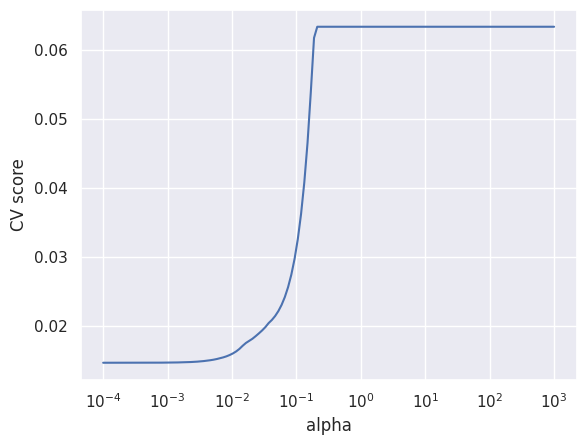

In [ ]:
from sklearn.model_selection import GridSearchCV
# Берем данные с категориальными признаками
x_train_cv,x_test_cv = dropData(x_train,x_test,'(count$|album_name$|track_name$|artists$|track_genre$)')
# Отнормировали
x_train_cv,x_test_cv = scalledData(x_train_cv,x_test_cv)
# Выбираем диапозон alpha
alphas = np.logspace(-4, 3, 140)
#Будем искать по сетке
searcher = GridSearchCV(Lasso(), [{"alpha": alphas}], scoring="neg_mean_squared_error", cv=4)

searcher.fit(x_train_cv, y_train)

best_alpha = searcher.best_params_["alpha"]
best_rmse = np.sqrt(-searcher.best_score_)
print("Best alpha = %.4f" % best_alpha)
print("Best rmse = %.4f" % best_rmse)

plt.plot(alphas, -searcher.cv_results_["mean_test_score"])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV score")



## Gradient Descent

#### 7. [3.5 points] Implement Ridge regression for MSE loss trained using gradient descent.

All computations must be vectorized, and Python loops can only be used for gradient descent iterations. The stopping criteria must be (simultaneously):

* checking the absolute norm of the difference in weights on two adjacent iterations (e.g., less than some small number of the order of $10^{-6}$, specified by the `tolerance` parameter);

* reaching the maximum number of iterations (e.g., 10000, specified by the `max_iter` parameter).

You need to do:

* Full gradient descent:

$$
w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

* Stochastic Gradient Descent:

$$
w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} q_{i_{k}}(w_{k}).
$$

$\nabla_{w} q_{i_{k}}(w_{k}) \, $ is an estimate of the gradient over a set of objects chosen at random.

* Moment of method:

$$
h_0 = 0, \\
h_{k + 1} = \alpha h_{k} + \eta_k \nabla_{w} Q(w_{k}), \\
w_{k + 1} = w_{k} - h_{k + 1}.
$$

* Adagrad method:

$$
G_0 = 0, \\
G_{k + 1} = G_{k} + (\nabla_{w} Q(w_{k+1}))^2, \\
w_{k + 1} = w_{k} - \eta * \frac{\nabla_{w} Q(w_{k+1})}{\sqrt{G_{k+1} + \epsilon}}.
$$

To verify that the optimization process is actually running, we will use the `loss_history` class attribute. After calling the fit method, it should contain the loss function values ​​for all iterations starting from the first (up to the first step along the antigradient).

You need to initialize the weights with a random vector from a normal distribution. Below is a template that should contain code implementing all the model variants.

In [ ]:
from sklearn.base import BaseEstimator

class LinReg(BaseEstimator):
    def __init__(self, delta=1.0, gd_type='Momentum',
                 tolerance=1e-4, max_iter=1000, w0=None, eta=1e-2, alpha=1e-3):
        """
        gd_type: str
            'GradientDescent', 'StochasticDescent', 'Momentum', 'Adagrad'
        delta: float
            proportion of object in a batch (for stochastic GD)
        tolerance: float
            for stopping gradient descent
        max_iter: int
            maximum number of steps in gradient descent
        w0: np.array of shape (d)
            init weights
        eta: float
            learning rate
        alpha: float
            momentum coefficient
        reg_cf: float
            regularization coefficient
        epsilon: float
            numerical stability
        """

        self.delta = delta
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.alpha = alpha
        self.w = None
        self.eta = eta
        self.loss_history = None # list of loss function values at each training iteration

    def fit(self, X, y):
        """
        X: np.array of shape (l, d)
        y: np.array of shape (l)
        ---
        output: self
        """
        self.loss_history = []

        return self

    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')

        pass

    def calc_gradient(self, X, y):
        """
        X: np.array of shape (l, d) (l can be equal to 1 if stochastic)
        y: np.array of shape (l)
        ---
        output: np.array of shape (d)
        """
        pass

    def calc_loss(self, X, y):
        """
        X: np.array of shape (l, d)
        y: np.array of shape (l)
        ---
        output: float
        """
        pass

#### 8. [1 point] Train and validate "manual" models on the same data, compare the quality with models from Sklearn and StatsModels. Investigate the influence of the `max_iter` and `alpha` parameters on the optimization process. Does it meet your expectations?

In [ ]:
# your code here
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

#### 9. [1 point] Plot graphs of the loss function values ​​as a function of the iteration number for all models (full gradient descent, stochastic gc, Momentum, and Adagrad). Draw conclusions about the convergence rate of various modifications of gradient descent.

Don't forget about what a *nice* graph should look like!

In [ ]:
# your code here
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ